In [161]:
# Dependencies
from matplotlib import pyplot as plt
# from scipy import stats
# from scipy.stats import linregress
import seaborn as sns
# import seaborn.objects as so 
import numpy as np
import pandas as pd
# from prophet import Prophet
# import datetime as dt
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
# from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# from scipy.stats import chi2_contingency
# from sklearn.linear_model import LogisticRegression
# from sklearn.preprocessing import StandardScaler

%matplotlib inline

In [162]:
# Load the data as a data frame
df = pd.read_csv("./Resources/HR_Analytics.csv")

### Exploration of the Data

In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1480 entries, 0 to 1479
Data columns (total 38 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmpID                     1480 non-null   object 
 1   Age                       1480 non-null   int64  
 2   AgeGroup                  1480 non-null   object 
 3   Attrition                 1480 non-null   object 
 4   BusinessTravel            1480 non-null   object 
 5   DailyRate                 1480 non-null   int64  
 6   Department                1480 non-null   object 
 7   DistanceFromHome          1480 non-null   int64  
 8   Education                 1480 non-null   int64  
 9   EducationField            1480 non-null   object 
 10  EmployeeCount             1480 non-null   int64  
 11  EmployeeNumber            1480 non-null   int64  
 12  EnvironmentSatisfaction   1480 non-null   int64  
 13  Gender                    1480 non-null   object 
 14  HourlyRa

In [164]:
# Viewing column names in the data frame 
df.columns

Index(['EmpID', 'Age', 'AgeGroup', 'Attrition', 'BusinessTravel', 'DailyRate',
       'Department', 'DistanceFromHome', 'Education', 'EducationField',
       'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender',
       'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole',
       'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'SalarySlab',
       'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StandardHours', 'StockOptionLevel', 'TotalWorkingYears',
       'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany',
       'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [165]:
display(df.head())
display(df.describe())

,EmpID,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM297,18,18-25,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,...,3,80,0,0,2,3,0,0,0,0.0
1,RM302,18,18-25,No,Travel_Rarely,812,Sales,10,3,Medical,...,1,80,0,0,2,3,0,0,0,0.0
2,RM458,18,18-25,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,...,4,80,0,0,3,3,0,0,0,0.0
3,RM728,18,18-25,No,Non-Travel,287,Research & Development,5,2,Life Sciences,...,4,80,0,0,2,3,0,0,0,0.0
4,RM829,18,18-25,Yes,Non-Travel,247,Research & Development,8,1,Medical,...,4,80,0,0,0,3,0,0,0,0.0


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1480.000000,1480.000000,1480.000000,1480.000000,1480.0,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,...,1480.000000,1480.0,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1480.000000,1423.000000
mean,36.917568,801.384459,9.220270,2.910811,1.0,1031.860811,2.724324,65.845270,2.729730,2.064865,...,2.708784,80.0,0.791892,11.281757,2.797973,2.760811,7.009459,4.228378,2.182432,4.118060
std,9.128559,403.126988,8.131201,1.023796,0.0,605.955046,1.092579,20.328266,0.713007,1.105574,...,1.081995,0.0,0.850527,7.770870,1.288791,0.707024,6.117945,3.616020,3.219357,3.555484
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,493.750000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,800.000000,7.000000,3.000000,1.0,1027.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1568.250000,4.000000,83.000000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


### Preparing the Data

In [166]:
def calculate_happiness(row):
    # Define the factors and their corresponding weights
    factors = {
        'JobSatisfaction': 0.25,
        'WorkLifeBalance': 0.20,
        'EnvironmentSatisfaction': 0.20,
        'RelationshipSatisfaction': 0.15,
        # 'SalarySatisfaction': 0.20
    }
    
    # Calculate the weighted sum of the factors, ignoring missing values
    total_weighted_sum = sum(row[factor] * weight for factor, weight in factors.items() if pd.notnull(row[factor]))
    
    # Calculate the sum of the weights for non-missing factors
    total_weights = sum(weight for factor, weight in factors.items() if pd.notnull(row[factor]))
    
    # Calculate the weighted average happiness
    weighted_avg = total_weighted_sum / total_weights if total_weights > 0 else None
    
    # Apply a non-linear transformation (e.g., sigmoid function) to normalize the happiness score
    happiness = 1 / (1 + np.exp(-weighted_avg)) if weighted_avg is not None else None
    
    return happiness

In [167]:
for col in df.columns:
    if len(df[col].unique()) == 1:
        print(f"{col}: {df[col].unique()}")

EmployeeCount: [1]
Over18: ['Y']
StandardHours: [80]


In [168]:
# Remove irrelevant columns
del df['EmpID'] # not relevant to this

# Remove columns that always have the same value
del df['StandardHours'] # always 80
del df['EmployeeCount'] # always 1
del df['Over18'] # always 'Y'

# Create a new column to indicate if an employee left the company
df['Churn'] = df['Attrition'].map({'Yes': 1, 'No': 0})

# Create a column to see the proportion of work hisotry at the company
df["ProportionAtCompany"] = np.where(df["TotalWorkingYears"] == 0, 1, df["YearsAtCompany"] / df["TotalWorkingYears"])

# Apply the function to each row in the dataframe and create a new column 'Happiness'
df['Happiness'] = df.apply(calculate_happiness, axis=1)

#Variables
variables = ['AgeGroup','SalarySlab', 'Department']

In [169]:
# eyeball the columns to better sort them into categorical and numerical groups since the charts differ based on the data forms
# dont want to just use objects as categorical since this is meant to be more discrete vs continuous
# ie Education is categorical despite being integers
for col in df.columns:
    if len(df[col].unique()) <= 10:
        print(f"{col}: {df[col].unique()}")

AgeGroup: ['18-25' '26-35' '36-45' '46-55' '55+']
Attrition: ['Yes' 'No']
BusinessTravel: ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel' 'TravelRarely']
Department: ['Research & Development' 'Sales' 'Human Resources']
Education: [3 2 1 4 5]
EducationField: ['Life Sciences' 'Medical' 'Marketing' 'Technical Degree' 'Other'
 'Human Resources']
EnvironmentSatisfaction: [3 4 2 1]
Gender: ['Male' 'Female']
JobInvolvement: [3 2 1 4]
JobLevel: [1 2 3 4 5]
JobRole: ['Laboratory Technician' 'Sales Representative' 'Research Scientist'
 'Human Resources' 'Manufacturing Director' 'Sales Executive'
 'Healthcare Representative' 'Research Director' 'Manager']
JobSatisfaction: [3 2 4 1]
MaritalStatus: ['Single' 'Divorced' 'Married']
SalarySlab: ['Upto 5k' '5k-10k' '10k-15k' '15k+']
NumCompaniesWorked: [1 0 5 6 3 2 9 8 7 4]
OverTime: ['No' 'Yes']
PerformanceRating: [3 4]
RelationshipSatisfaction: [3 1 4 2]
StockOptionLevel: [0 2 1 3]
TrainingTimesLastYear: [2 3 0 5 4 6 1]
WorkLifeBalance: [3 4 1 2]
C

In [170]:
cat_cols = ['AgeGroup', 'BusinessTravel', 'Department',
            'Education', 'EducationField', 'EnvironmentSatisfaction',
            'Gender', 'JobInvolvement', 'JobLevel', 'JobRole',
            'JobSatisfaction', 'MaritalStatus', 'SalarySlab',
            'OverTime', 'PerformanceRating', 'RelationshipSatisfaction',
            'StockOptionLevel', 'WorkLifeBalance']

num_cols = ['Age', 'DailyRate', 'DistanceFromHome',
            'HourlyRate', 'MonthlyIncome', 'MonthlyRate',
            'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears',
            'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 
            'YearsSinceLastPromotion', 'YearsWithCurrManager', 'ProportionAtCompany']

In [171]:
display(df[cat_cols])
display(df[num_cols])

,AgeGroup,BusinessTravel,Department,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,SalarySlab,OverTime,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,WorkLifeBalance
0,18-25,Travel_Rarely,Research & Development,3,Life Sciences,3,Male,3,1,Laboratory Technician,3,Single,Upto 5k,No,3,3,0,3
1,18-25,Travel_Rarely,Sales,3,Medical,4,Female,2,1,Sales Representative,3,Single,Upto 5k,No,3,1,0,3
2,18-25,Travel_Frequently,Sales,3,Marketing,2,Male,3,1,Sales Representative,2,Single,Upto 5k,Yes,3,4,0,3
3,18-25,Non-Travel,Research & Development,2,Life Sciences,2,Male,3,1,Research Scientist,4,Single,Upto 5k,No,3,4,0,3
4,18-25,Non-Travel,Research & Development,1,Medical,3,Male,3,1,Laboratory Technician,3,Single,Upto 5k,No,3,4,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1475,55+,Travel_Rarely,Research & Development,3,Life Sciences,1,Female,3,5,Manager,1,Married,15k+,No,3,4,0,1
1476,55+,Travel_Frequently,Sales,3,Marketing,3,Female,2,3,Sales Executive,1,Married,10k-15k,No,3,4,0,4
1477,55+,Travel_Rarely,Sales,4,Marketing,1,Male,3,2,Sales Executive,1,Single,5k-10k,No,3,4,0,3
1478,55+,Travel_Rarely,Sales,4,Marketing,2,Male,4,2,Sales Executive,4,Divorced,5k-10k,Yes,3,2,1,3


,Age,DailyRate,DistanceFromHome,HourlyRate,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,ProportionAtCompany
0,18,230,3,54,1420,25233,1,13,0,2,0,0,0,0.0,1.000000
1,18,812,10,69,1200,9724,1,12,0,2,0,0,0,0.0,1.000000
2,18,1306,5,69,1878,8059,1,14,0,3,0,0,0,0.0,1.000000
3,18,287,5,73,1051,13493,1,15,0,2,0,0,0,0.0,1.000000
4,18,247,8,80,1904,13556,1,12,0,0,0,0,0,0.0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1475,60,422,7,41,19566,3854,5,11,33,5,29,8,11,10.0,0.878788
1476,60,1499,28,80,10266,2845,4,19,22,5,18,13,13,11.0,0.818182
1477,60,1179,16,84,5405,11924,8,14,10,1,2,2,2,2.0,0.200000
1478,60,696,7,52,5220,10893,0,18,12,3,11,7,1,9.0,0.916667


### Visualizations

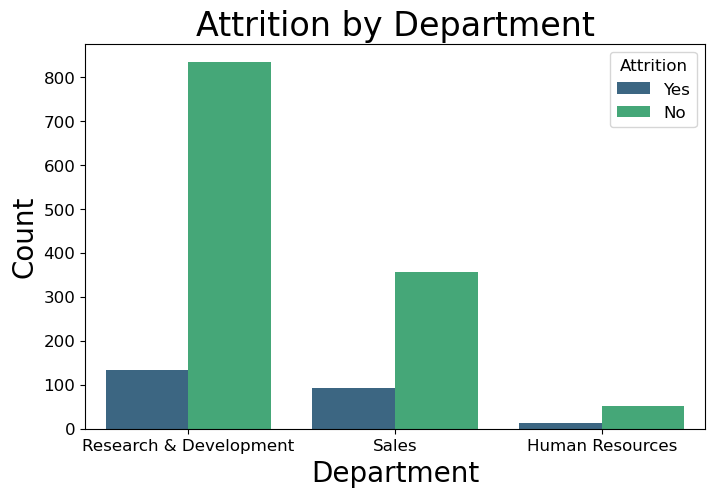

In [172]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Department', hue='Attrition', palette='viridis')
plt.title('Attrition by Department')
plt.xlabel('Department')
plt.ylabel('Count')
plt.legend(title='Attrition')
plt.show()

# This code is showing the attrition by department. Research and Development had the most. 

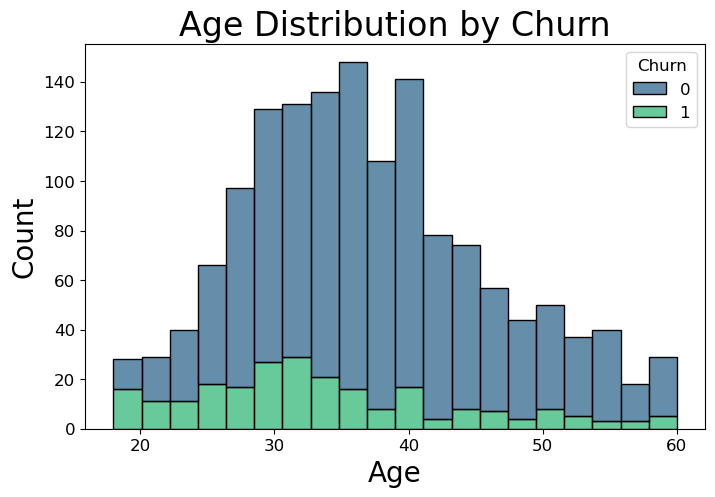

In [173]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', hue='Churn', multiple='stack', bins=20, palette='viridis')
plt.title('Age Distribution by Churn')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

# Shows how churn varies between different age groups 



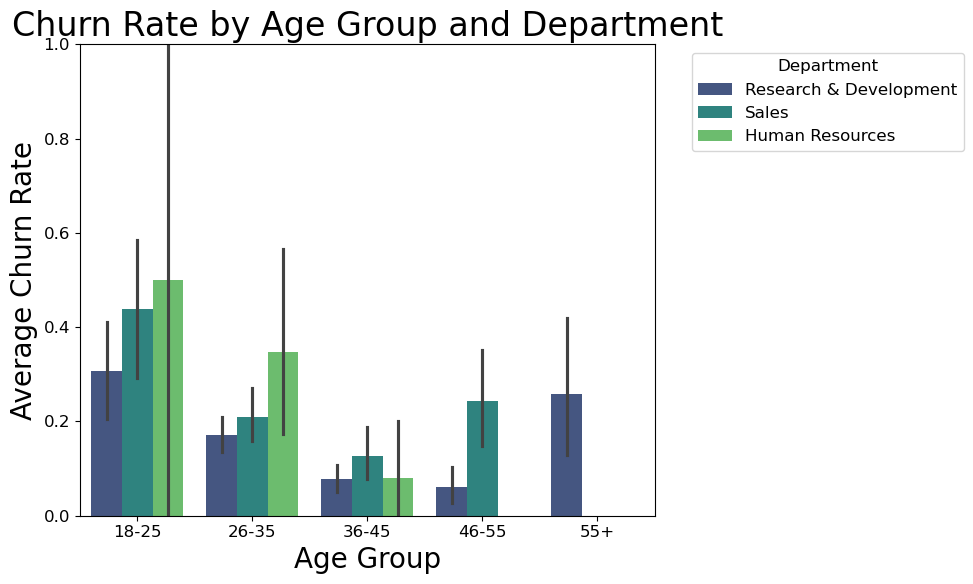

In [174]:
plt.figure(figsize=(10, 6))
# sns.barplot(data=churn_age_department, x='AgeGroup', y='Churn', hue='Department', palette='viridis')
sns.barplot(data=df, x='AgeGroup', y='Churn', hue='Department', palette='viridis')
plt.title('Churn Rate by Age Group and Department')
plt.xlabel('Age Group')
plt.ylabel('Average Churn Rate')
plt.ylim(0, 1)  # Limit the y-axis to show rates between 0 and 1
plt.legend(title='Department', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()  # Adjust layout for better fit
plt.show()

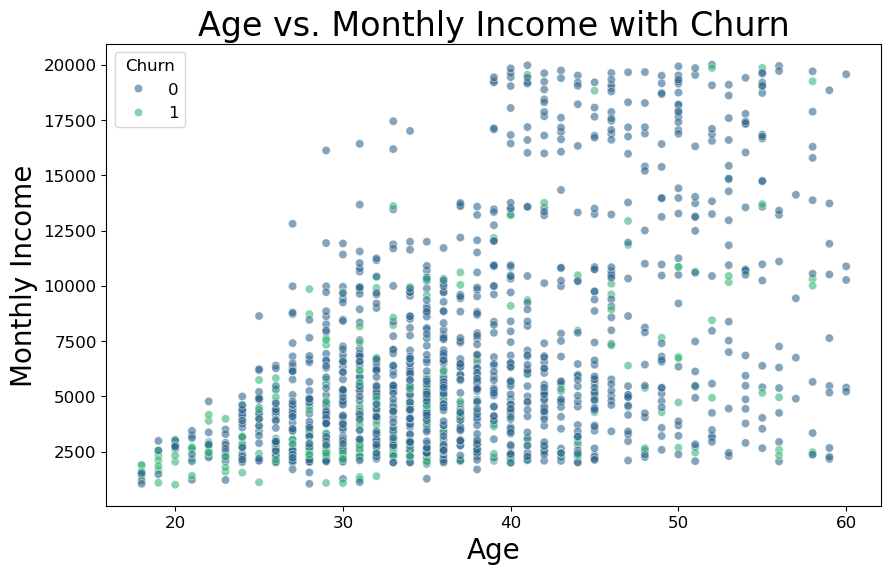

In [175]:
plt.figure(figsize=(10, 6))
if 'MonthlyIncome' in df.columns:
    sns.scatterplot(data=df, x='Age', y='MonthlyIncome', hue='Churn', alpha=0.6, palette='viridis')
    plt.title('Age vs. Monthly Income with Churn')
    plt.xlabel('Age')
    plt.ylabel('Monthly Income')
else:
    print("Column 'MonthlyIncome' not found. Adjust the y-axis column for this plot.")
plt.show()

# A scatter plot that provides a direct view of how age and salary correlate with the liklihood of churn 

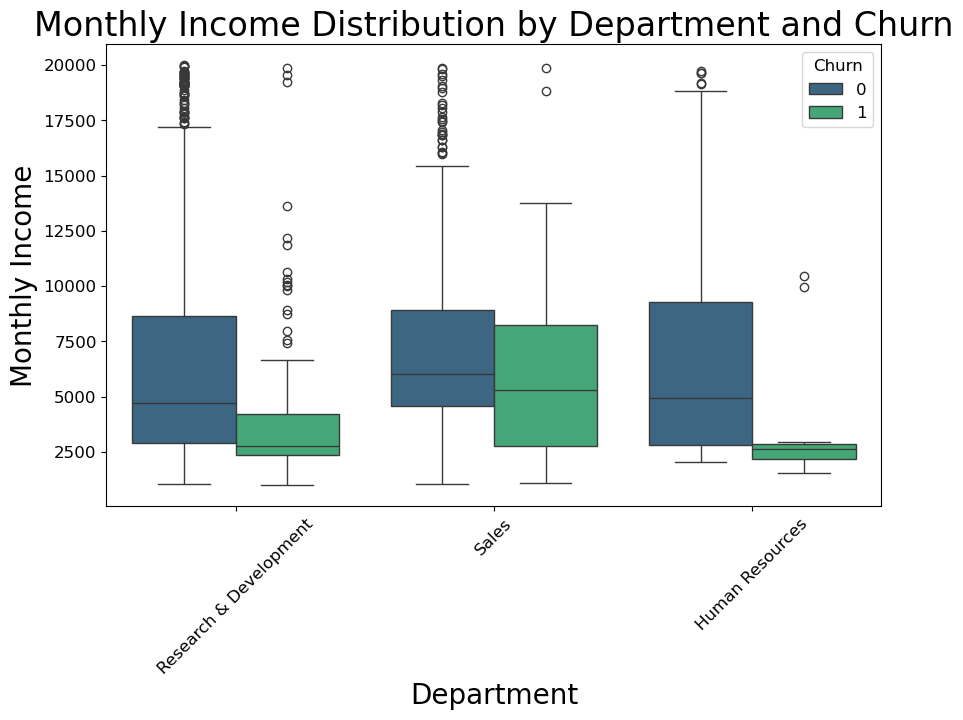

In [176]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Department', y='MonthlyIncome', hue='Churn', palette='viridis')
plt.title('Monthly Income Distribution by Department and Churn')
plt.xlabel('Department')
plt.ylabel('Monthly Income')
plt.legend(title='Churn', loc='upper right')
plt.xticks(rotation=45)
plt.show()

# This shows the spread of monthly income by department and how it relates to churn 



C:\Users\fsgin\AppData\Local\Temp\ipykernel_16796\2861611495.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_age_department = df.groupby(['AgeGroup', 'Department'])['Churn'].mean().unstack()


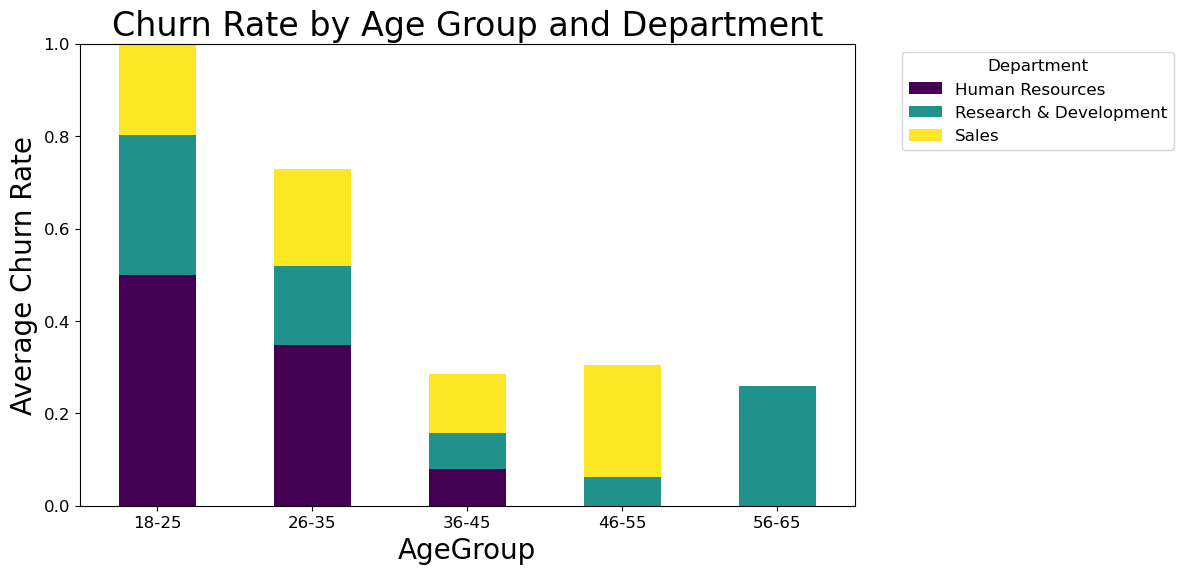

In [177]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[18, 25, 35, 45, 55, 65], labels=['18-25', '26-35', '36-45', '46-55', '56-65'])
churn_age_department = df.groupby(['AgeGroup', 'Department'])['Churn'].mean().unstack()
churn_age_department.plot(kind='bar', figsize=(10, 6), stacked=True, colormap='viridis')
plt.title('Churn Rate by Age Group and Department')
plt.ylabel('Average Churn Rate')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title='Department', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Shows churn rate within each group, separated by departments 

C:\Users\fsgin\AppData\Local\Temp\ipykernel_16796\3574348535.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_income = df.pivot_table(values='MonthlyIncome', index='AgeGroup', columns='Department', aggfunc='mean')


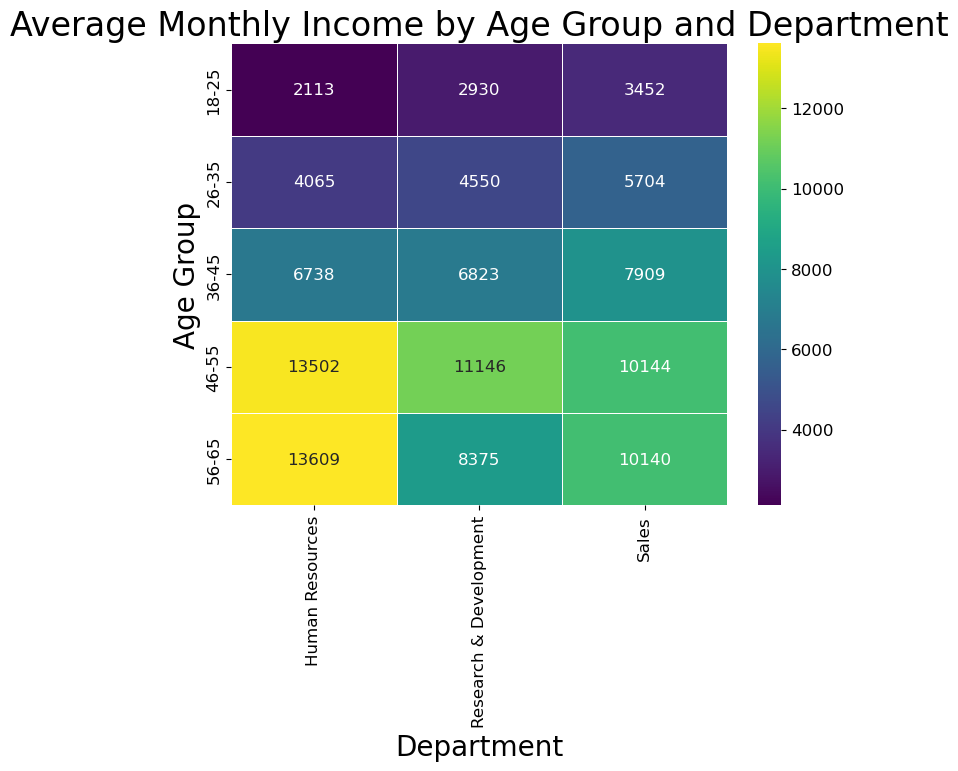

In [178]:
pivot_income = df.pivot_table(values='MonthlyIncome', index='AgeGroup', columns='Department', aggfunc='mean')
plt.figure(figsize=(8, 6))
sns.heatmap(pivot_income, annot=True, fmt='.0f', cmap='viridis', linewidths=0.5)
plt.title('Average Monthly Income by Age Group and Department')
plt.xlabel('Department')
plt.ylabel('Age Group')
plt.show()


In [179]:
summary_stats = df.groupby('Churn')[['Age', 'MonthlyIncome']].mean()
print("Average Age and Monthly Income by Churn Status:")
print(summary_stats)

# Average age and income of employees who left and stayed 

Average Age and Monthly Income by Churn Status:
             Age  MonthlyIncome
Churn                          
0      37.538647    6829.294686
1      33.676471    4812.584034


In [180]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[18, 25, 35, 45, 55, 65], labels=['18-25', '26-35', '36-45', '46-55', '56-65'])
churn_age_department = df.groupby(['AgeGroup', 'Department'])['Churn'].mean().reset_index()
print("\nChurn Rate by Age Group and Department:")
print(churn_age_department)

# Highest churn rate by age group, and which department they are in. 
# Human Resources


Churn Rate by Age Group and Department:
   AgeGroup              Department     Churn
0     18-25         Human Resources  0.500000
1     18-25  Research & Development  0.301370
2     18-25                   Sales  0.421053
3     26-35         Human Resources  0.347826
4     26-35  Research & Development  0.170483
5     26-35                   Sales  0.210256
6     36-45         Human Resources  0.080000
7     36-45  Research & Development  0.078370
8     36-45                   Sales  0.125984
9     46-55         Human Resources  0.000000
10    46-55  Research & Development  0.061644
11    46-55                   Sales  0.243243
12    56-65         Human Resources  0.000000
13    56-65  Research & Development  0.258065
14    56-65                   Sales  0.000000


C:\Users\fsgin\AppData\Local\Temp\ipykernel_16796\2553005269.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_age_department = df.groupby(['AgeGroup', 'Department'])['Churn'].mean().reset_index()


In [181]:
# This provides a quick overview of the linear relationships between these variables.
correlation_matrix = df[['Age', 'MonthlyIncome', 'Churn']].corr()
print("\nCorrelation Matrix for Age, Monthly Income, and Churn:")
print(correlation_matrix)


Correlation Matrix for Age, Monthly Income, and Churn:
                    Age  MonthlyIncome     Churn
Age            1.000000       0.497486 -0.155476
MonthlyIncome  0.497486       1.000000 -0.157672
Churn         -0.155476      -0.157672  1.000000


C:\Users\fsgin\AppData\Local\Temp\ipykernel_16796\3214122095.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  corr = df.groupby([variable, 'Churn']).size().unstack('Churn').fillna(0)


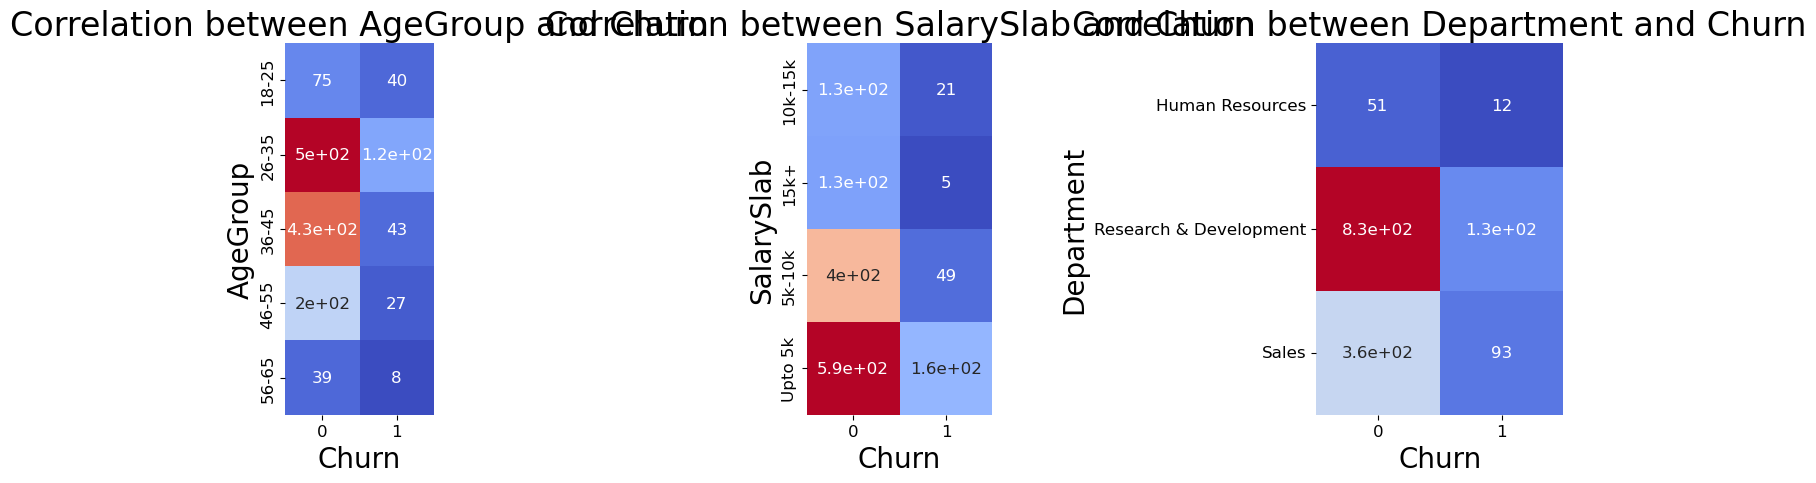

In [182]:
#Plot the correlations as heatmaps 
fig, axs = plt.subplots(1, len(variables), figsize=(15,5))
for i, variable in enumerate(variables):
    corr = df.groupby([variable, 'Churn']).size().unstack('Churn').fillna(0)
    sns.heatmap(corr, annot=True, cmap='coolwarm', square=True, ax=axs[i], cbar=False)
    axs[i].set_title(f'Correlation between {variable} and Churn')
plt.tight_layout()
plt.show()   

In [183]:
# Churn features 
x = df.drop('Churn', axis= 1)
y = df['Churn']

In [184]:
# Training and testing sets
x_train, x_test, y_train, y_test = train_test_split\
    (x, y, test_size=0.2, random_state=42)
dt_model = DecisionTreeClassifier(random_state=42)

In [185]:
# Identify non-numericals
# Encode non-numericals as a new column in the dataframe
# Fit the model with the encoded data

non_numerical_features = x_train.select_dtypes(exclude=['number'])
x_train_encoded = pd.get_dummies\
    (x_train, columns=non_numerical_features.columns)
dt_model.fit(x_train_encoded, y_train)

DecisionTreeClassifier(random_state=42)

In [186]:
# Encode x_test 
common_columns = x_test.columns.intersection(x_train.columns)
x_test_encoded = pd.get_dummies(x_test, columns = common_columns)
x_test_encoded = x_test_encoded.reindex\
    (columns=x_train_encoded.columns, fill_value=0)
y_pred = dt_model.predict(x_test_encoded)


In [187]:
# View model

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       249
           1       1.00      1.00      1.00        47

    accuracy                           1.00       296
   macro avg       1.00      1.00      1.00       296
weighted avg       1.00      1.00      1.00       296

Confusion Matrix:
[[249   0]
 [  0  47]]


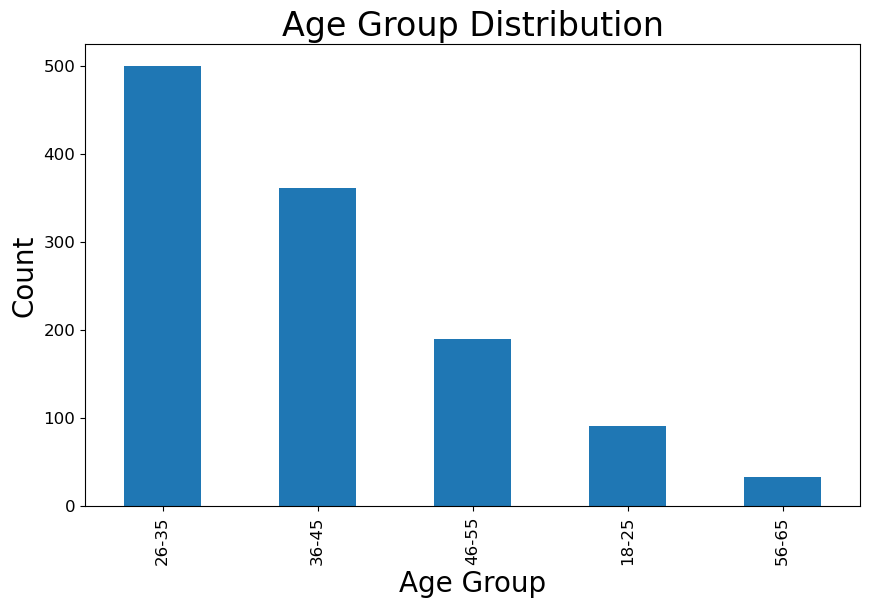

In [188]:
plt.figure(figsize=(10, 6))
x_train['AgeGroup'].value_counts().plot(kind='bar')
plt.title('Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.show()

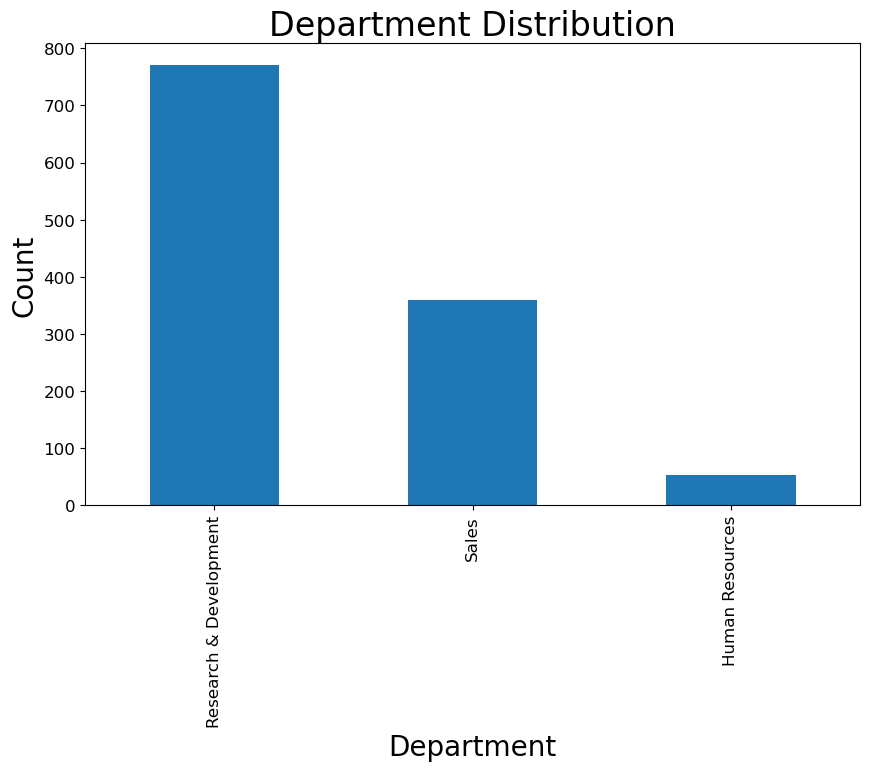

In [189]:
plt.figure(figsize=(10, 6))
x_train['Department'].value_counts().plot(kind='bar')
plt.title('Department Distribution')
plt.xlabel('Department')
plt.ylabel('Count')
plt.show()

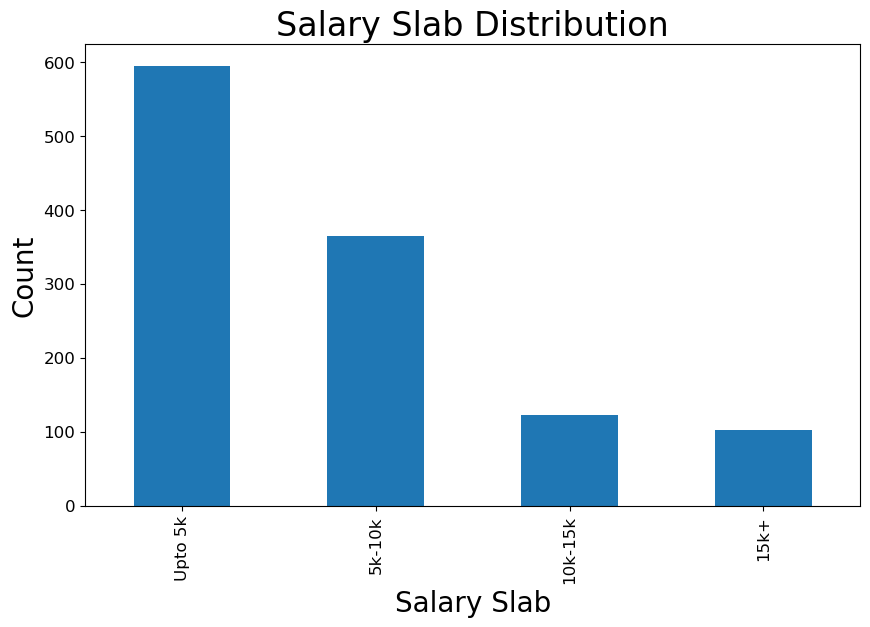

In [190]:
plt.figure(figsize=(10, 6))
x_train['SalarySlab'].value_counts().plot(kind='bar')
plt.title('Salary Slab Distribution')
plt.xlabel('Salary Slab')
plt.ylabel('Count')
plt.show()

C:\Users\fsgin\AppData\Local\Temp\ipykernel_16796\1983750895.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = pd.pivot_table(x_train, index='AgeGroup', \


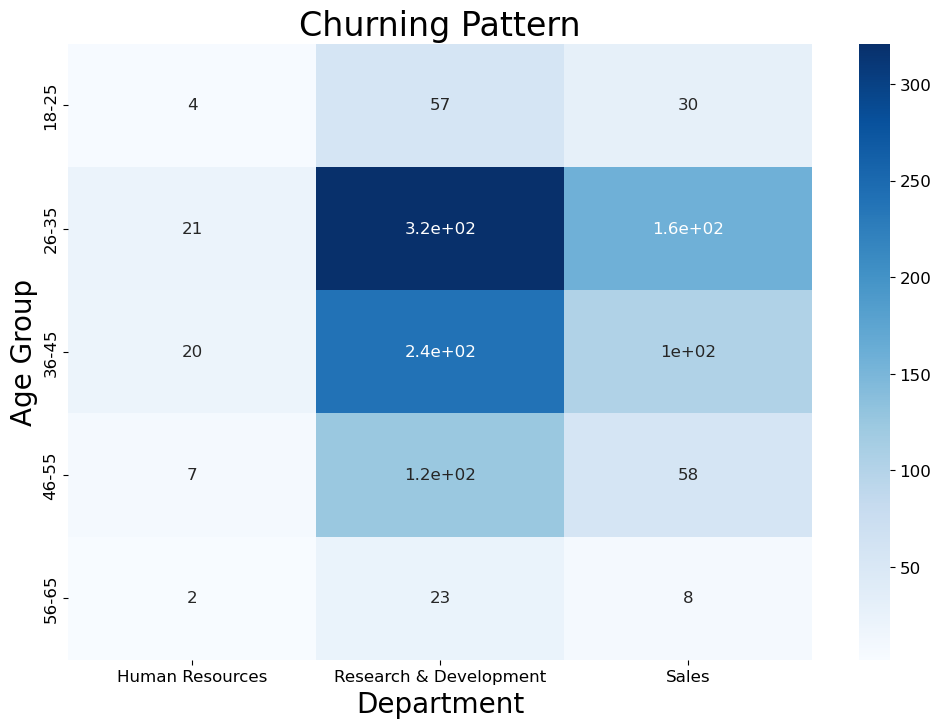

In [191]:
pivot_table = pd.pivot_table(x_train, index='AgeGroup', \
    columns='Department', values='SalarySlab', aggfunc='count')
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, annot=True, cmap='Blues')
plt.title('Churning Pattern')
plt.xlabel('Department')
plt.ylabel('Age Group')
plt.show()

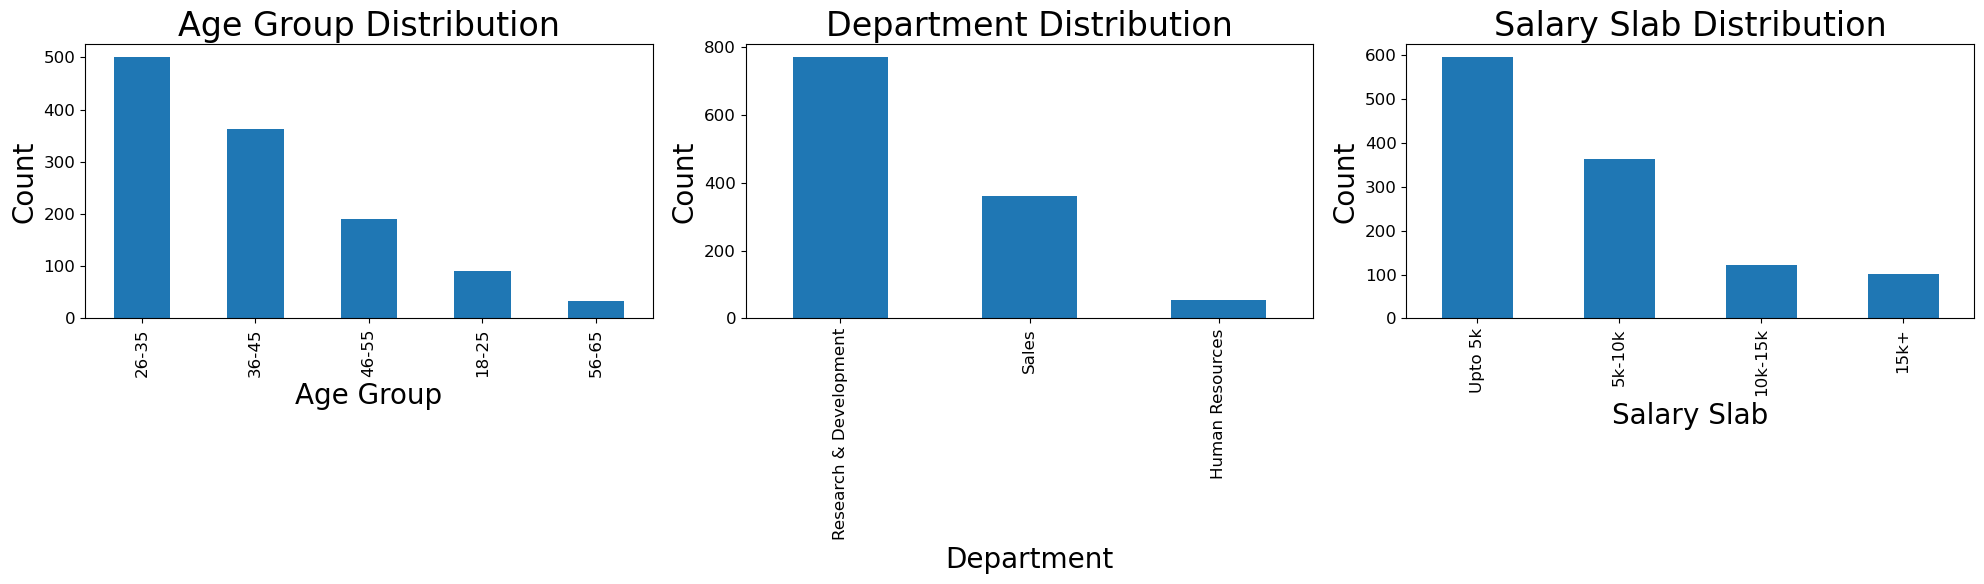

In [192]:
fig, axs = plt.subplots(1, 3, figsize=(20, 6))

# Plot AgeGroup
x_train['AgeGroup'].value_counts().plot(kind='bar', ax=axs[0])
axs[0].set_title('Age Group Distribution')
axs[0].set_xlabel('Age Group')
axs[0].set_ylabel('Count')

# Plot Department
x_train['Department'].value_counts().plot(kind='bar', ax=axs[1])
axs[1].set_title('Department Distribution')
axs[1].set_xlabel('Department')
axs[1].set_ylabel('Count')

# Plot SalarySlab
x_train['SalarySlab'].value_counts().plot(kind='bar', ax=axs[2])
axs[2].set_title('Salary Slab Distribution')
axs[2].set_xlabel('Salary Slab')
axs[2].set_ylabel('Count')

# Layout so plots do not overlap
fig.tight_layout()

plt.show()

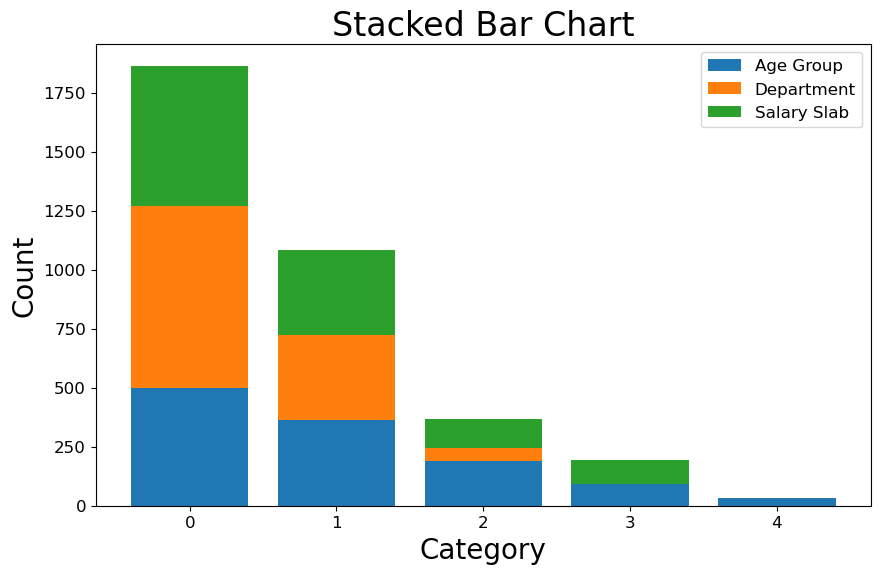

In [193]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot age group
age_counts = x_train['AgeGroup'].value_counts()
ax.bar(range(len(age_counts)), age_counts.values, label='Age Group')

# Plot department
dept_counts = x_train['Department'].value_counts()
max_len = max(len(age_counts), len(dept_counts))
bottom = np.zeros(max_len)
bottom[:len(age_counts)] = age_counts.values
ax.bar(range(len(dept_counts)), dept_counts.values, bottom=bottom[:len(dept_counts)], label='Department')

# Plot salary slab
salary_counts = x_train['SalarySlab'].value_counts()
max_len = max(max_len, len(salary_counts))
bottom[:len(dept_counts)] += dept_counts.values
ax.bar(range(len(salary_counts)), salary_counts.values, bottom=bottom[:len(salary_counts)], label='Salary Slab')

# Set title and labels
ax.set_title('Stacked Bar Chart')
ax.set_xlabel('Category')
ax.set_ylabel('Count')

# Legend
ax.legend()

plt.show()

In [194]:
# fig, ax = plt.subplots(figsize=(10, 6))

# # Plot age group vs department
# ax.scatter(x_train['AgeGroup'], x_train['Department'], label='Age Group vs Department')

# # Plot age group vs salary slab
# ax.scatter(x_train['AgeGroup'], x_train['SalarySlab'], label='Age Group vs Salary Slab')

# # Plot department vs salary slab
# ax.scatter(x_train['Department'], x_train['SalarySlab'], label='Department vs Salary Slab')

# # Set title and labels
# ax.set_title('Scatter Plot')
# ax.set_xlabel('Category')
# ax.set_ylabel('Category')

# # Legend
# ax.legend()

# plt.show()

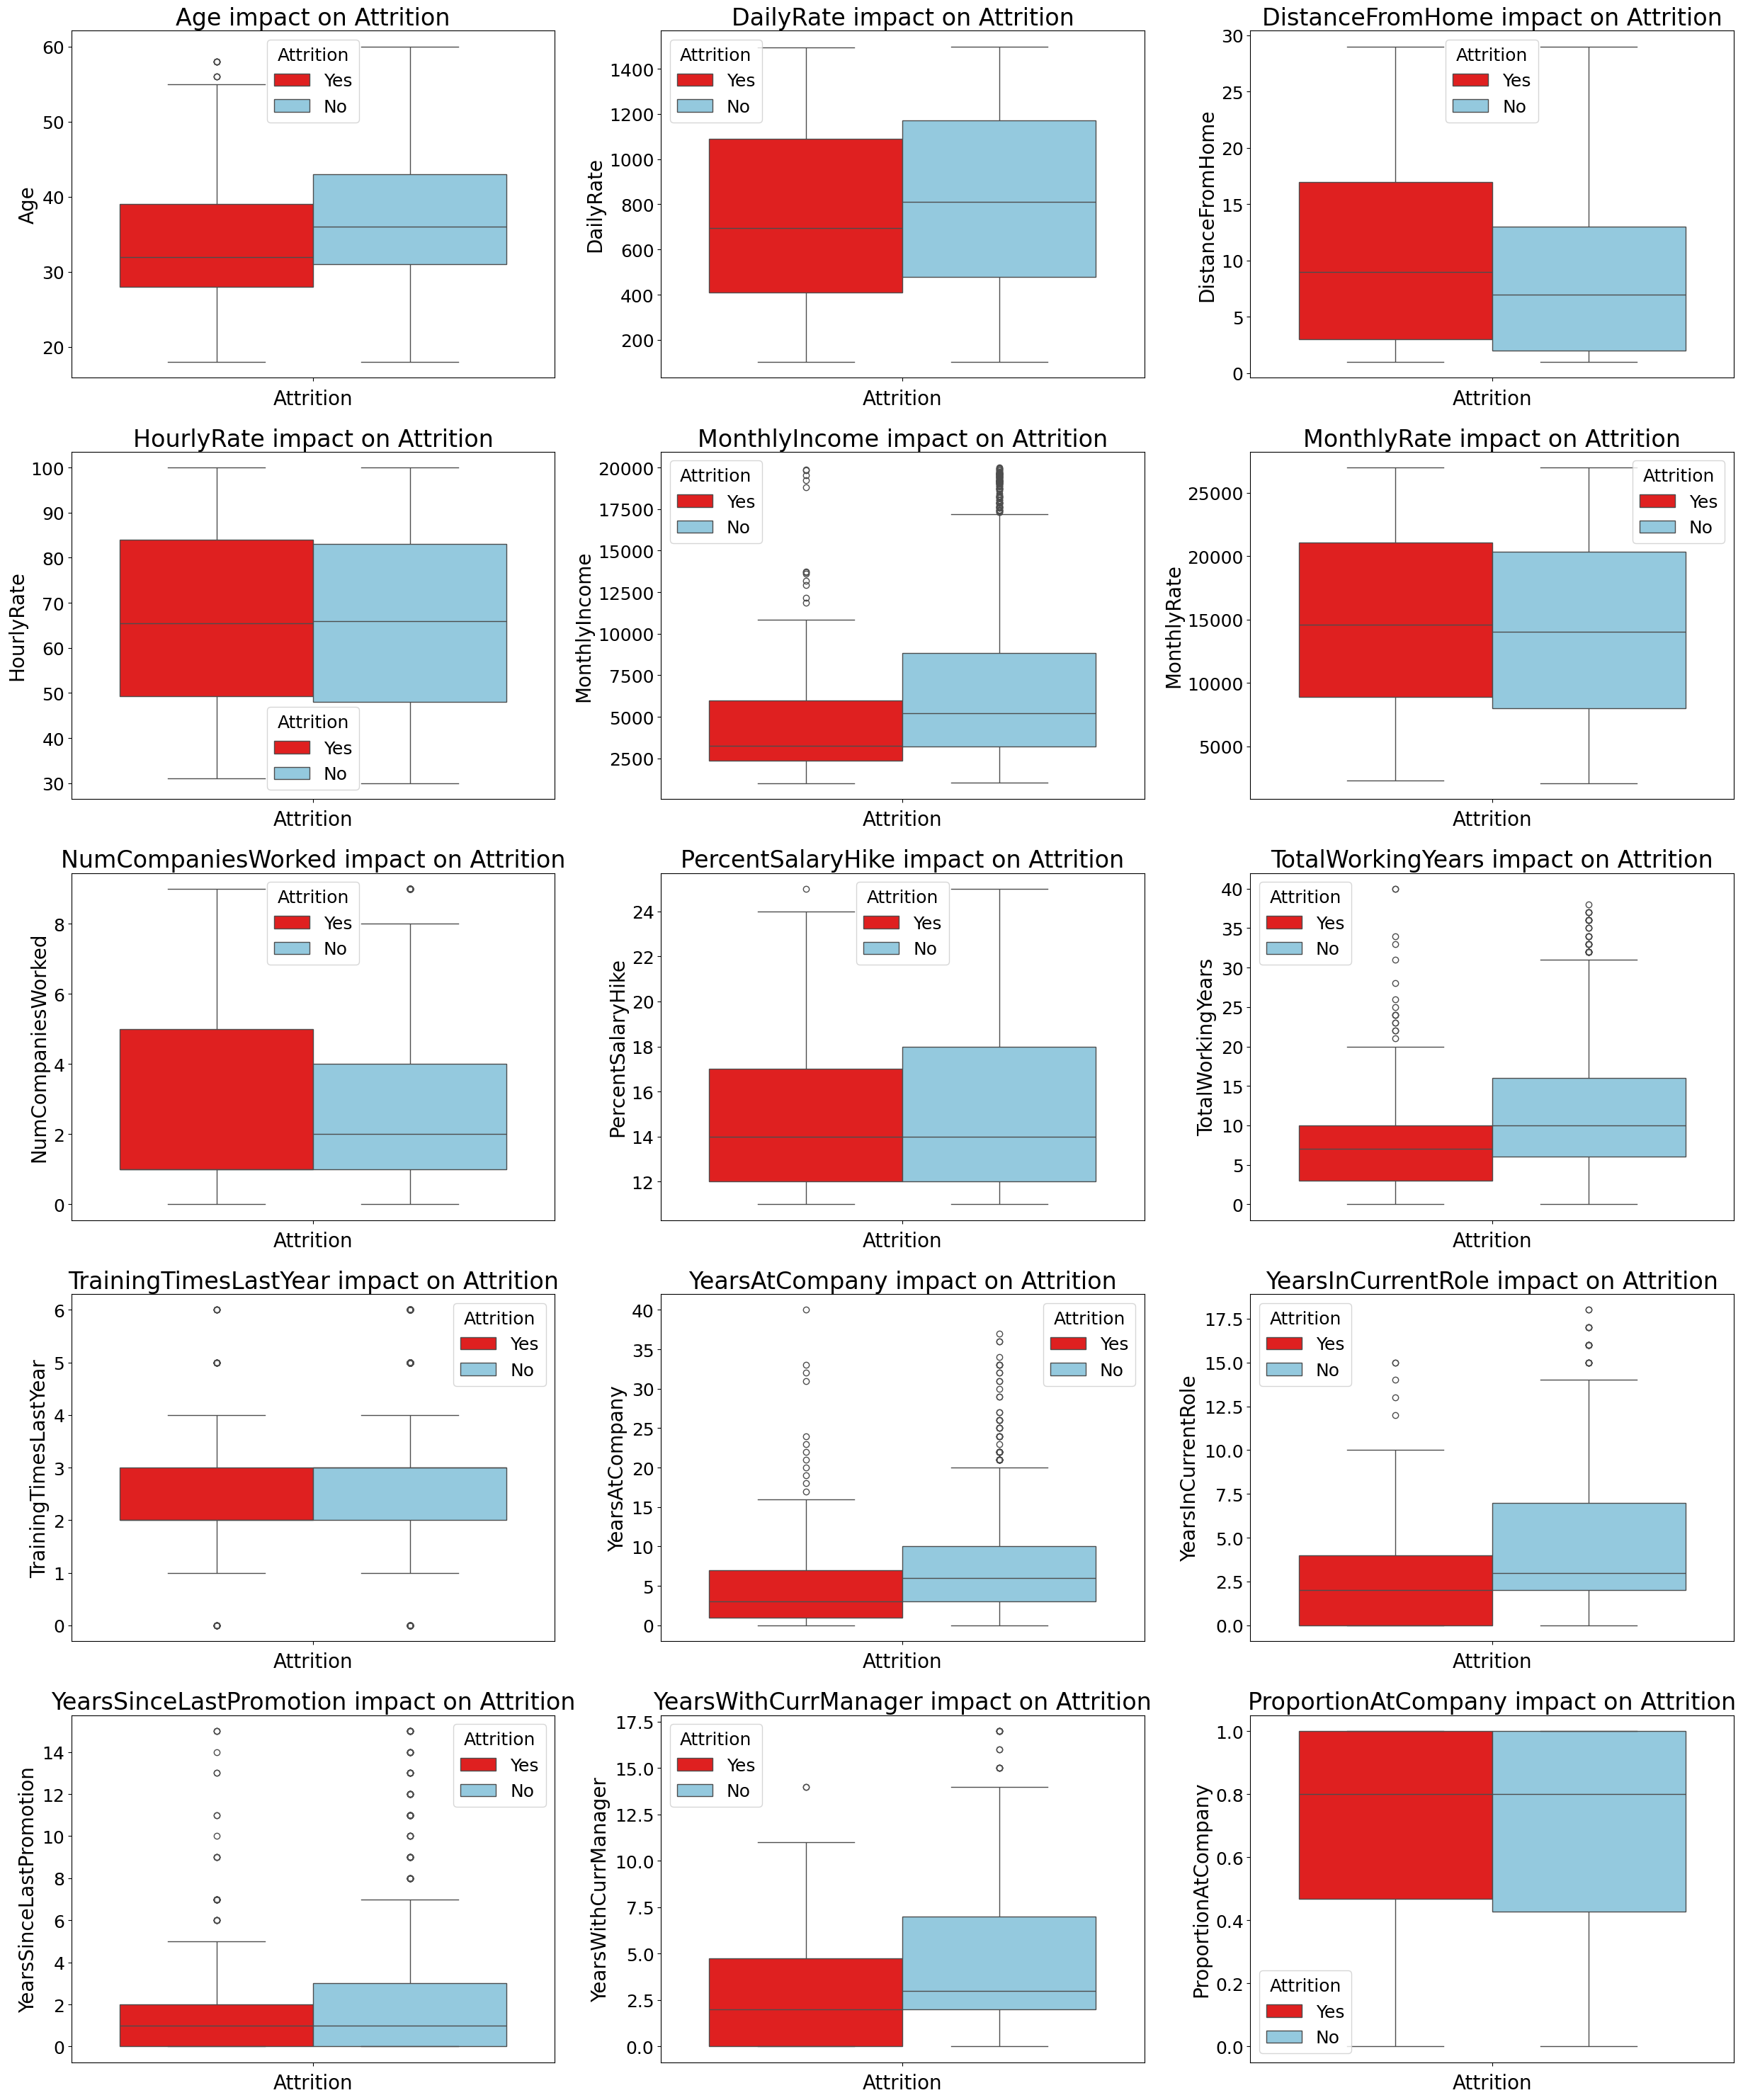

In [195]:
# Make box plots for all of the numerical data.
# We want to be able to visually compare them, see if we can see notable 
# differences that would be worth looking into 

plt.close()

plt.rcParams['font.size'] = 18
plt.rcParams['axes.titlesize'] = 24
plt.rcParams['axes.labelsize'] = 20

cols_per_row = 3
offset = 1
if len(num_cols) % cols_per_row == 0:
    offset = 0

fig, axes = plt.subplots(
    nrows=len(num_cols)//cols_per_row + offset,
    ncols=cols_per_row, 
    figsize=(25, len(num_cols)*2)
)

# Flatten axes array for easy iteration
axes = axes.flatten()

for i, col in enumerate(num_cols): # numerical colums charted with boxplots
    sns.boxplot(
        hue='Attrition',
        y=col,
        data=df,
        ax=axes[i],
        # color='red',
        palette=['red', 'skyblue'],
        linewidth=1,
    )
    axes[i].set_title(f'{col} impact on Attrition')
    axes[i].set_xlabel('Attrition')
    axes[i].set_ylabel(col)

# Remove any unused subplots
for i in range(i + 1, len(axes)):
    fig.delaxes(axes[i])

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

C:\Users\fsgin\AppData\Local\Temp\ipykernel_16796\3052424243.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = df.groupby(['Attrition', col]).size().unstack(fill_value=0)


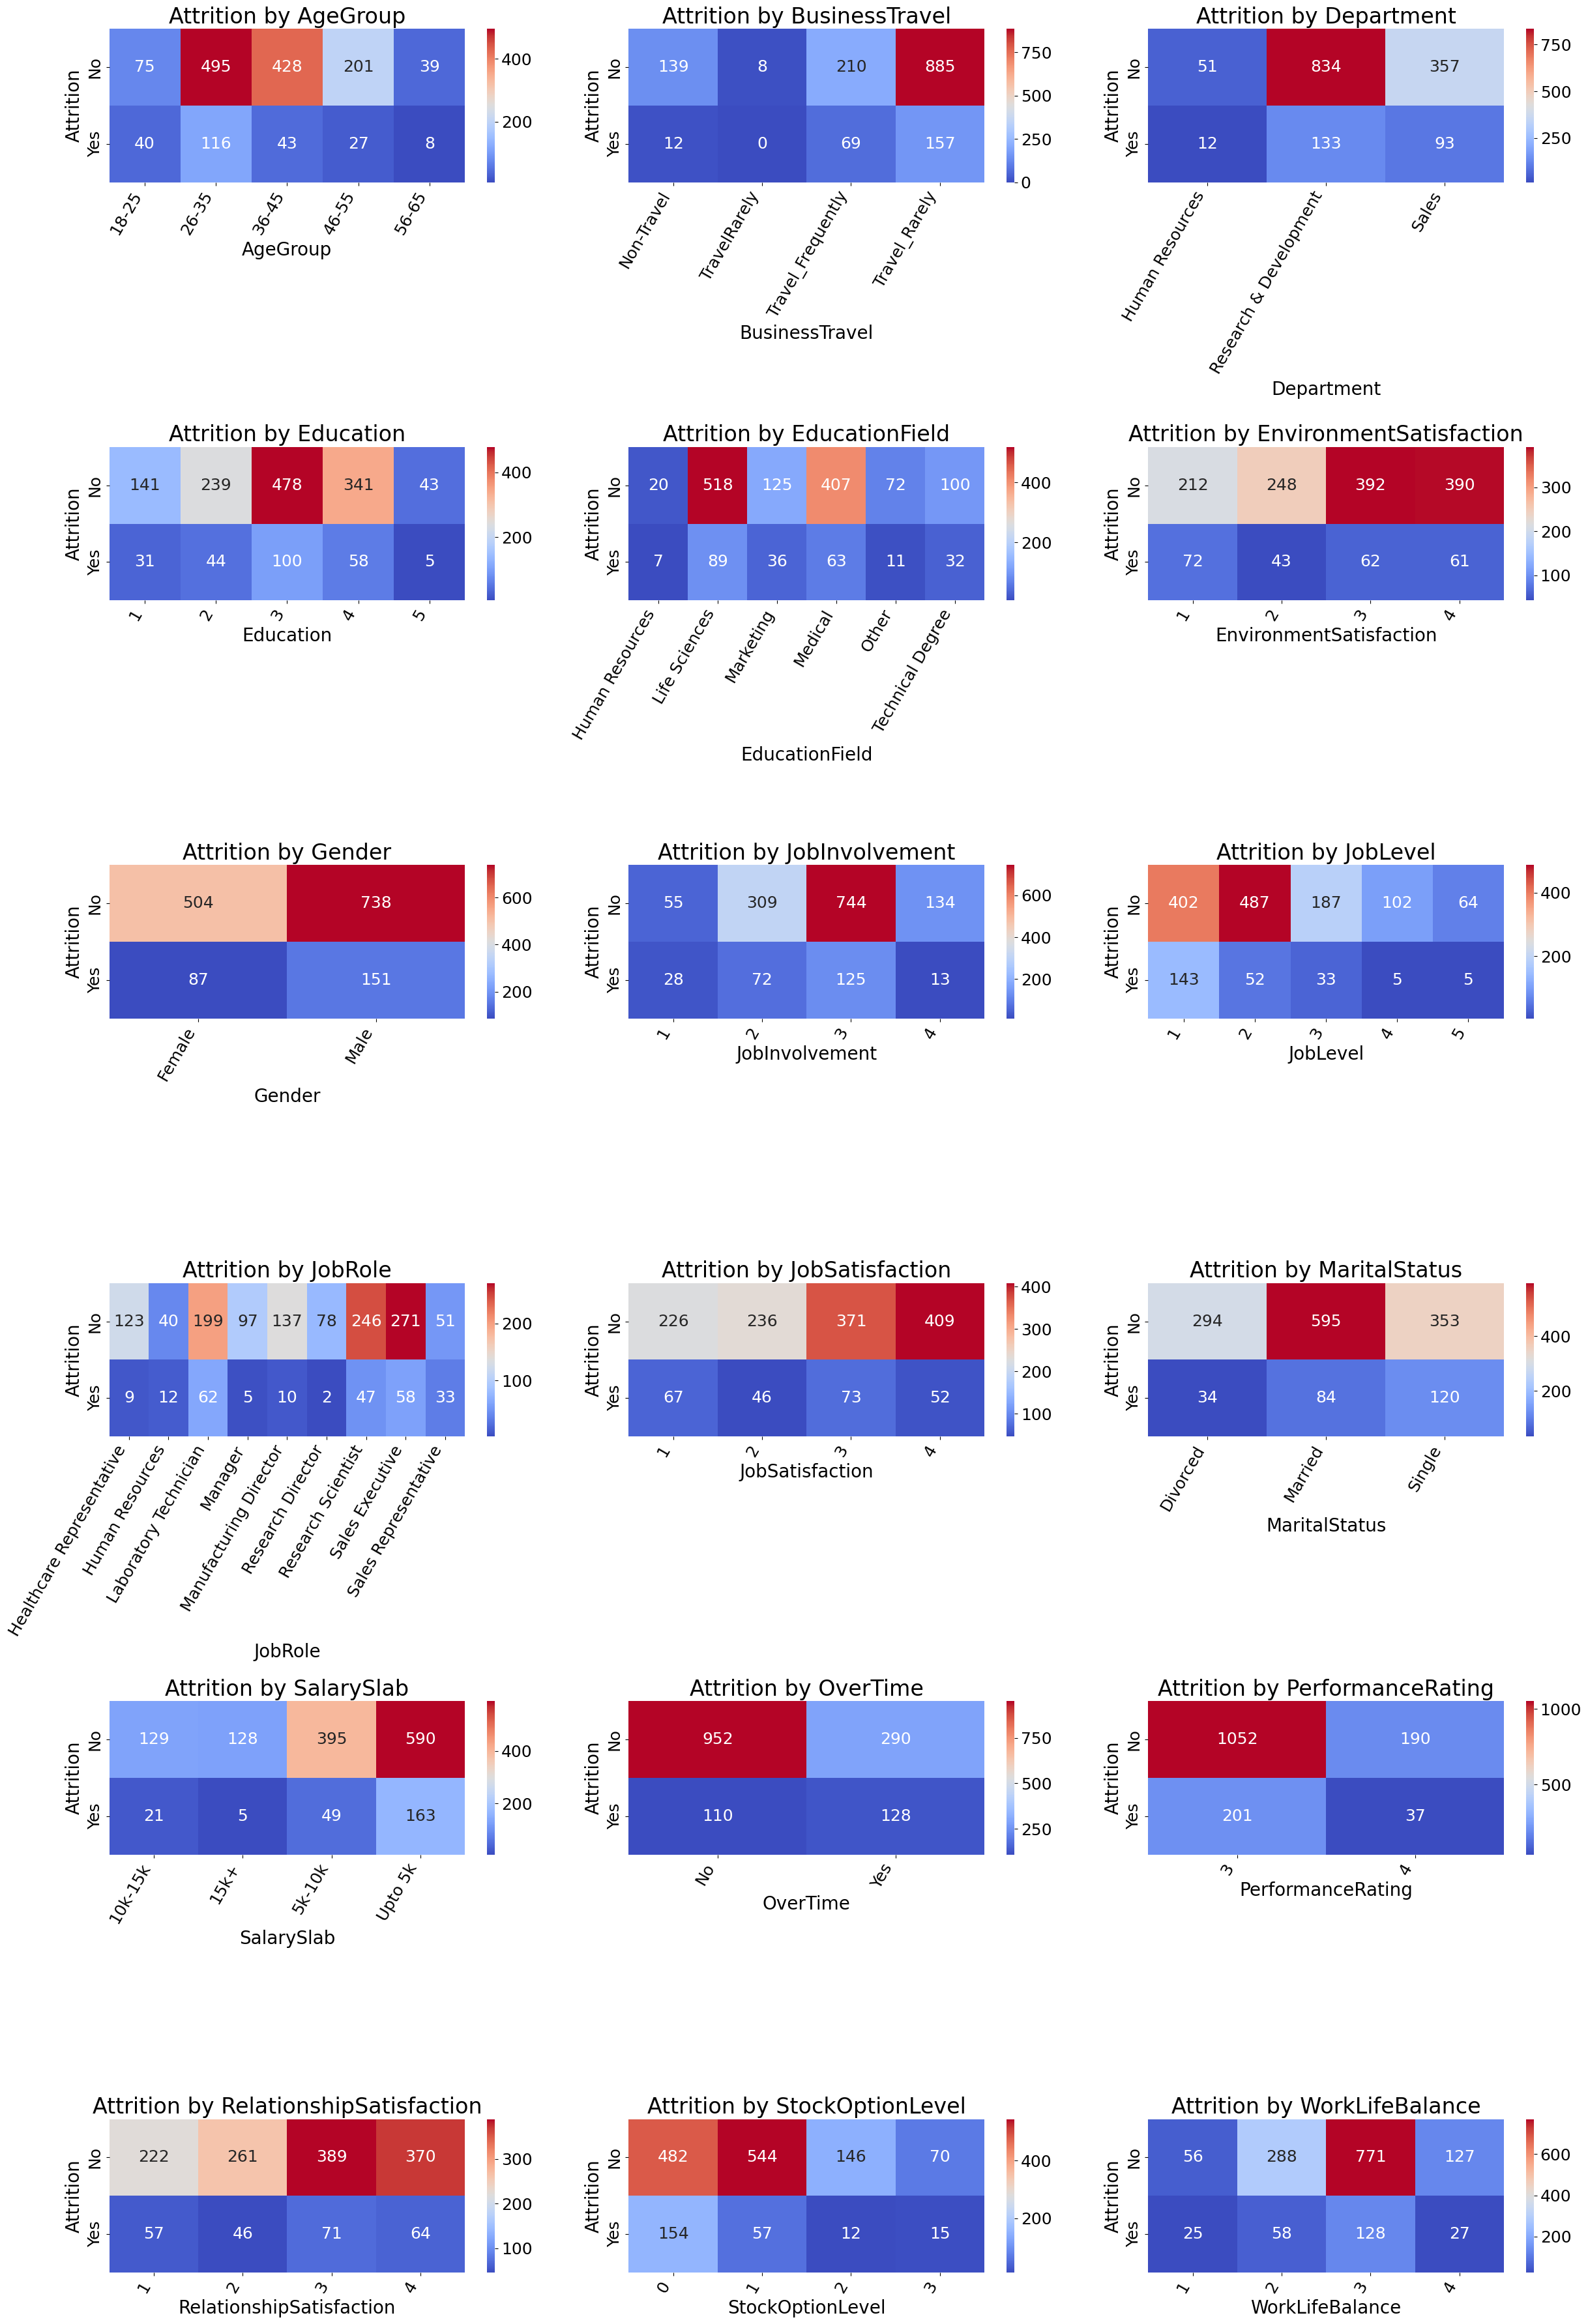

In [196]:
plt.close()

plt.rcParams['font.size'] = 18
plt.rcParams['axes.titlesize'] = 24
plt.rcParams['axes.labelsize'] = 20

cols_per_row = 3
offset = 1
if len(cat_cols) % cols_per_row == 0:
    offset = 0

fig, axes = plt.subplots(
    nrows=len(cat_cols)//cols_per_row + offset,
    ncols=cols_per_row, 
    figsize=(25, len(cat_cols)*2)
)

# Flatten axes array for easy iteration
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Create a pivot table for the heatmap
    heatmap_data = df.groupby(['Attrition', col]).size().unstack(fill_value=0)

    # Create a heatmap
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt='d',
        cmap='coolwarm',
        ax=axes[i],
        cbar=True,
    )

    # Set titles and labels
    axes[i].set_title(f'Attrition by {col}')
    axes[i].set_ylabel('Attrition')
    axes[i].set_xlabel(col)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=60, ha='right')

# Remove any unused subplots
for i in range(i+1, len(axes)):
    fig.delaxes(axes[i])

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

C:\Users\fsgin\AppData\Local\Temp\ipykernel_16796\3579272609.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attrition_by_col = df.groupby(['Attrition', col]).size().unstack(fill_value=0)


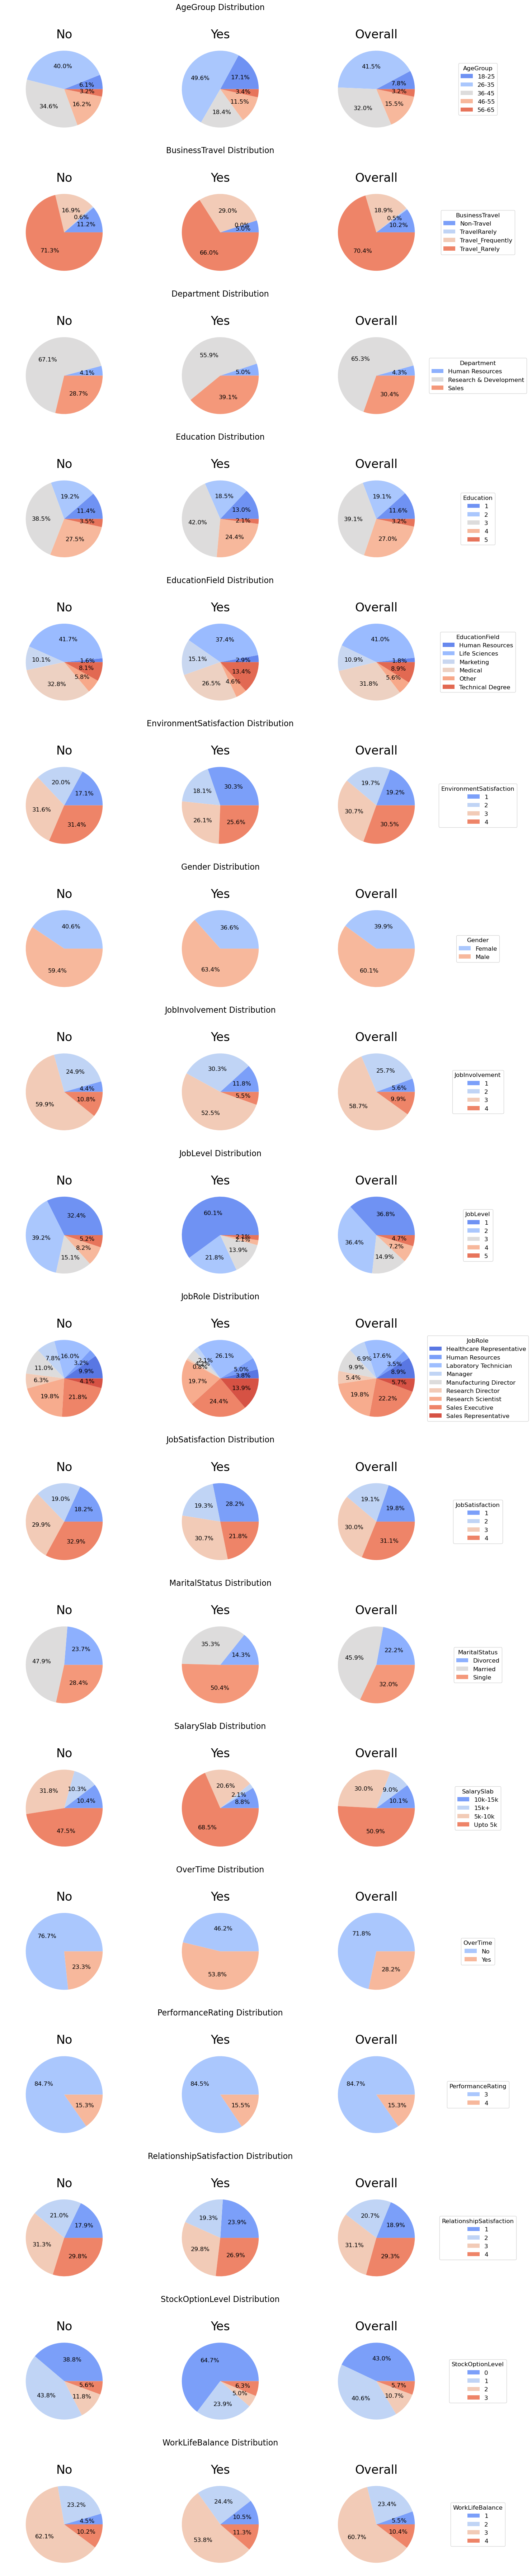

In [197]:
plt.close()

plt.rcParams['font.size'] = 12

# Define number of rows and columns for the grid layout
cols_per_row = 4  # No Yes Overall Legend
num_rows = len(cat_cols) * 2  # Title Row followed by Chart Row

fig = plt.figure(figsize=(15, len(cat_cols) * 4))
gs = fig.add_gridspec(
    num_rows, 
    cols_per_row, 
    width_ratios=[1, 1, 1, 0.1], 
    height_ratios=[.1,1] * len(cat_cols)
    )

for i, col in enumerate(cat_cols):
    # Position for the row title (spanning the first three columns)
    row_title = fig.add_subplot(gs[i * 2, :3])
    row_title.set_title(f'{col} Distribution', fontsize=16)
    row_title.axis('off')  # Hide the axis for title row

    # Group data by Attrition and the current categorical column
    attrition_by_col = df.groupby(['Attrition', col]).size().unstack(fill_value=0)
    
    # Create pie chart for "No" in Attrition
    no_counts = attrition_by_col.loc['No']
    ax_no = fig.add_subplot(gs[i * 2 + 1, 0])  # First column for "No" pie chart
    ax_no.pie(no_counts, autopct='%1.1f%%', colors=sns.color_palette('coolwarm', len(no_counts)))
    ax_no.set_title(f'No')
    
    # Create pie chart for "Yes" in Attrition
    yes_counts = attrition_by_col.loc['Yes']
    ax_yes = fig.add_subplot(gs[i * 2 + 1, 1])  # Second column for "Yes" pie chart
    ax_yes.pie(yes_counts, autopct='%1.1f%%', colors=sns.color_palette('coolwarm', len(yes_counts)))
    ax_yes.set_title(f'Yes')
    
    # Create pie chart for overall distribution
    total_counts = no_counts + yes_counts
    ax_total = fig.add_subplot(gs[i * 2 + 1, 2])  # Third column for overall pie chart
    wedges_total, texts_total, autotexts_total = ax_total.pie(total_counts, autopct="%1.1f%%", colors=sns.color_palette('coolwarm', len(total_counts)))
    ax_total.set_title(f'Overall')
    # ax_total.legend(wedges_total, total_counts.index, title=col, loc='center left')
    
    # Add a legend in the last column
    ax_legend = fig.add_subplot(gs[i * 2 + 1, 3])  # Fourth column for the legend
    ax_legend.legend(wedges_total, total_counts.index, title=col, loc='center')
    ax_legend.axis('off')  # Hide axes around legend

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()


In [198]:
numerical_df = df.copy()
numerical_df['AgeGroup'] = numerical_df['AgeGroup'].replace({'18-25': 0, '26-35': 1, '36-45': 2, '46-55': 3, '56-65': 4, '55+': 5})
numerical_df['Attrition'] = numerical_df['Attrition'].replace({'Yes': 1, 'No': 0})
numerical_df['BusinessTravel'] = numerical_df['BusinessTravel'].replace({'Travel_Rarely': 1, 'Travel_Frequently': 2, 'Non-Travel': 0, 'TravelRarely': 1})
numerical_df['Department'] = numerical_df['Department'].replace({'Research & Development': 0, 'Sales': 1, 'Human Resources': 2})
numerical_df['EducationField'] = numerical_df['EducationField'].replace({'Life Sciences': 0, 'Medical': 1, 'Marketing': 2, 'Technical Degree': 3, 'Other': 4, 'Human Resources': 5})
numerical_df['Gender'] = numerical_df['Gender'].replace({'Male': 1, 'Female': 0})
numerical_df['JobRole'] = numerical_df['JobRole'].replace({'Laboratory Technician': 0, 'Sales Representative': 1, 'Research Scientist': 2,
                                                            'Human Resources': 3, 'Manufacturing Director': 4, 'Sales Executive': 5,
                                                            'Healthcare Representative': 6, 'Research Director': 7, 'Manager': 8})
numerical_df['MaritalStatus'] = numerical_df['MaritalStatus'].replace({'Single': 0, 'Divorced': 1, 'Married': 2})
numerical_df['SalarySlab'] = numerical_df['SalarySlab'].replace({'Upto 5k': 0, '5k-10k': 1, '10k-15k': 2, '15k+': 3})
numerical_df['OverTime'] = numerical_df['OverTime'].replace({'No': 0, 'Yes': 1})

numerical_df

C:\Users\fsgin\AppData\Local\Temp\ipykernel_16796\1022497798.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  numerical_df['AgeGroup'] = numerical_df['AgeGroup'].replace({'18-25': 0, '26-35': 1, '36-45': 2, '46-55': 3, '56-65': 4, '55+': 5})
C:\Users\fsgin\AppData\Local\Temp\ipykernel_16796\1022497798.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  numerical_df['AgeGroup'] = numerical_df['AgeGroup'].replace({'18-25': 0, '26-35': 1, '36-45': 2, '46-55': 3, '56-65': 4, '55+': 5})
C:\Users\fsgin\AppData\Local\Temp\ipykernel_16796\1022497798.py

,Age,AgeGroup,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,...,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Churn,ProportionAtCompany,Happiness
0,18,NaN,1,1,230,0,3,3,0,405,...,0,2,3,0,0,0,0.0,1,1.000000,0.952574
1,18,NaN,0,1,812,1,10,3,1,411,...,0,2,3,0,0,0,0.0,0,1.000000,0.946597
2,18,NaN,1,2,1306,1,5,3,2,614,...,0,3,3,0,0,0,0.0,1,1.000000,0.932453
3,18,NaN,0,0,287,0,5,2,0,1012,...,0,2,3,0,0,0,0.0,0,1.000000,0.962673
4,18,NaN,1,0,247,0,8,1,1,1156,...,0,0,3,0,0,0,0.0,1,1.000000,0.960361
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1475,60,4,0,1,422,0,7,3,0,549,...,33,5,1,29,8,11,10.0,0,0.878788,0.826712
1476,60,4,0,2,1499,1,28,3,2,573,...,22,5,4,18,13,13,11.0,0,0.818182,0.943348
1477,60,4,0,1,1179,1,16,4,2,732,...,10,1,3,2,2,2,2.0,0,0.200000,0.887205
1478,60,4,0,1,696,1,7,4,2,1233,...,12,3,3,11,7,1,9.0,0,0.916667,0.946597


In [199]:
numerical_df.corr()["Attrition"].sort_values(ascending=False)

Attrition                   1.000000
Churn                       1.000000
OverTime                    0.248331
BusinessTravel              0.125894
DistanceFromHome            0.080006
Department                  0.078896
EducationField              0.062642
NumCompaniesWorked          0.045336
Gender                      0.030191
MonthlyRate                 0.016585
PerformanceRating           0.002531
ProportionAtCompany        -0.001271
HourlyRate                 -0.008252
EmployeeNumber             -0.012376
PercentSalaryHike          -0.014603
Education                  -0.030144
YearsSinceLastPromotion    -0.032244
RelationshipSatisfaction   -0.045387
DailyRate                  -0.056976
TrainingTimesLastYear      -0.058415
WorkLifeBalance            -0.062646
EnvironmentSatisfaction    -0.101696
JobSatisfaction            -0.104232
JobInvolvement             -0.130769
YearsAtCompany             -0.135108
StockOptionLevel           -0.135140
AgeGroup                   -0.139158
M